[*] INITIATING EXPLAINABLE AI (SHAP) MODULE...
[*] Training Surrogate Random Forest Model for Interpretation...
[*] Calculating SHAP Game-Theory Values (This takes a few seconds)...

[+] Generating Figure 1: SHAP Summary Plot...


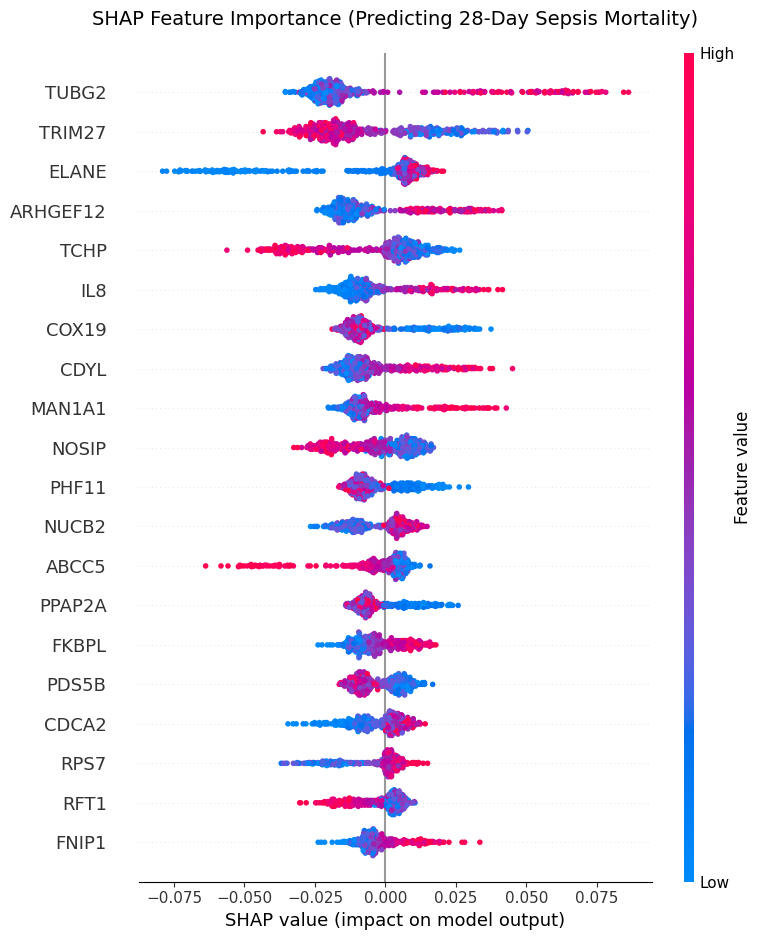


[!!!] High-Resolution Plot saved to: /workspace/data/processed/SHAP_Summary_Plot.png


In [4]:
import os
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import shap
import matplotlib.pyplot as plt

print("[*] INITIATING EXPLAINABLE AI (SHAP) MODULE...")

# 1. LOAD THE EUROPEAN TRAINING DATA (The Ground Truth)
processed_dir = "/workspace/data/processed"
clinical_df = pd.read_csv(os.path.join(processed_dir, "GSE65682_clinical_clean.csv"), index_col=0)
expr_df = pd.read_csv(os.path.join(processed_dir, "GSE65682_expression_TOP100.csv"), index_col=0)

# Load the translated Top 100 to get the real Gene Symbols
top_100_df = pd.read_csv(os.path.join(processed_dir, "top_100_translated.csv"))
probe_to_symbol = dict(zip(top_100_df['Gene_ID'].astype(str), top_100_df['Gene Symbol']))

# Merge Clinical and Genomic
full_df = clinical_df.join(expr_df, how='inner')

# Encode clinical targets
full_df['gender_num'] = full_df['gender'].apply(lambda x: 1 if x == 'male' else 0)
full_df['pneumonia'] = full_df['pneumonia diagnoses'].apply(lambda x: 1 if x == 'cap' else 0)
full_df['diabetes'] = full_df['diabetes_mellitus'].apply(lambda x: 1 if x == 'yes' else 0)

# Define Features and Target
clinical_features = ['age', 'gender_num', 'pneumonia', 'diabetes']
genomic_features = expr_df.columns.tolist()
all_features = clinical_features + genomic_features

X = full_df[all_features].copy()
y = full_df['mortality_event_28days'].values

# Rename the columns in X from Probe IDs to actual Gene Symbols
rename_dict = {probe: probe_to_symbol.get(probe, probe) for probe in genomic_features}
X.rename(columns=rename_dict, inplace=True)

# 2. TRAIN THE SURROGATE RANDOM FOREST MODEL
print("[*] Training Surrogate Random Forest Model for Interpretation...")
# We use class_weight='balanced' to handle the survivor/non-survivor imbalance
rf_model = RandomForestClassifier(n_estimators=150, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X, y)

# 3. CALCULATE SHAP VALUES
print("[*] Calculating SHAP Game-Theory Values (This takes a few seconds)...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X)

# Random Forest returns SHAP values for both classes (Survival=0, Death=1). We want to plot Death (Index 1).
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_to_plot = shap_values[:,:,1]
else:
    shap_values_to_plot = shap_values

# 4. GENERATE THE PUBLISHABLE SHAP SUMMARY PLOT
print("\n[+] Generating Figure 1: SHAP Summary Plot...")
plt.figure(figsize=(10, 8))
plt.title("SHAP Feature Importance (Predicting 28-Day Sepsis Mortality)", fontsize=14, pad=20)

# Plot the top 20 most important features
shap.summary_plot(shap_values_to_plot, X, max_display=20, show=False)

# Save the plot in high-resolution for the research paper
plot_path = os.path.join(processed_dir, "SHAP_Summary_Plot.png")
plt.tight_layout()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[!!!] High-Resolution Plot saved to: {plot_path}")